✓ GPU detected

===== LABEL ENCODER MAPS =====
gender: female → 0
gender: male → 1
bone_type: calcaneus → 0
bone_type: carpal → 1
bone_type: elbow → 2
bone_type: femur → 3
bone_type: fibula → 4
bone_type: finger → 5
bone_type: foot → 6
bone_type: hip join → 7
bone_type: humerus → 8
bone_type: knee → 9
bone_type: metacarpal → 10
bone_type: metatarsal → 11
bone_type: radius → 12
bone_type: shoulder → 13
bone_type: tarsal → 14
bone_type: tibia → 15
bone_type: ulna → 16
left_right: left → 0
left_right: right → 1
gap_visibility: no → 0
gap_visibility: slight → 1
gap_visibility: yes → 2
primary_observation: begin of bone → 0
primary_observation: callus present → 1
primary_observation: end of the bone → 2
primary_observation: looks normal → 3
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None,

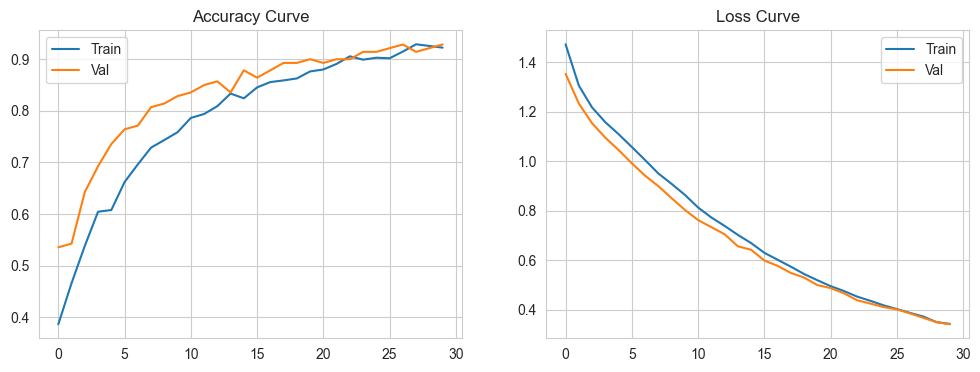

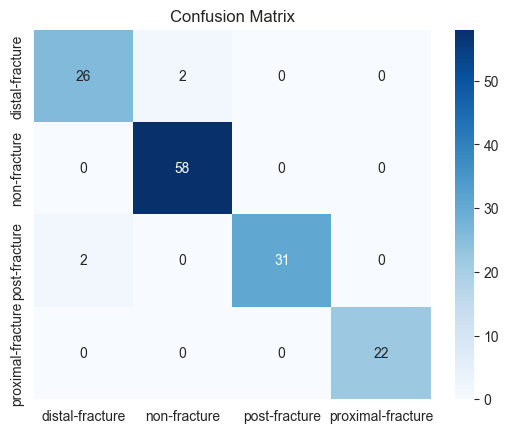

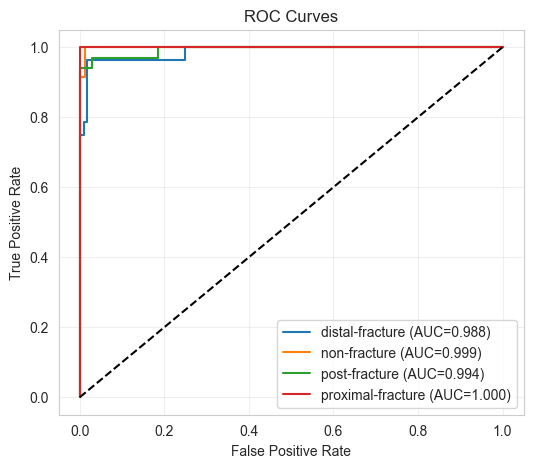


Classification Report:

                   precision    recall  f1-score   support

  distal-fracture       0.93      0.93      0.93        28
     non-fracture       0.97      1.00      0.98        58
    post-fracture       1.00      0.94      0.97        33
proximal-fracture       1.00      1.00      1.00        22

         accuracy                           0.97       141
        macro avg       0.97      0.97      0.97       141
     weighted avg       0.97      0.97      0.97       141

Cohen Kappa: 0.9600283486888731
Weighted F1: 0.9715297812237047

=== Grad-CAM & LIME per class ===


100%|██████████| 1000/1000 [00:13<00:00, 71.59it/s]


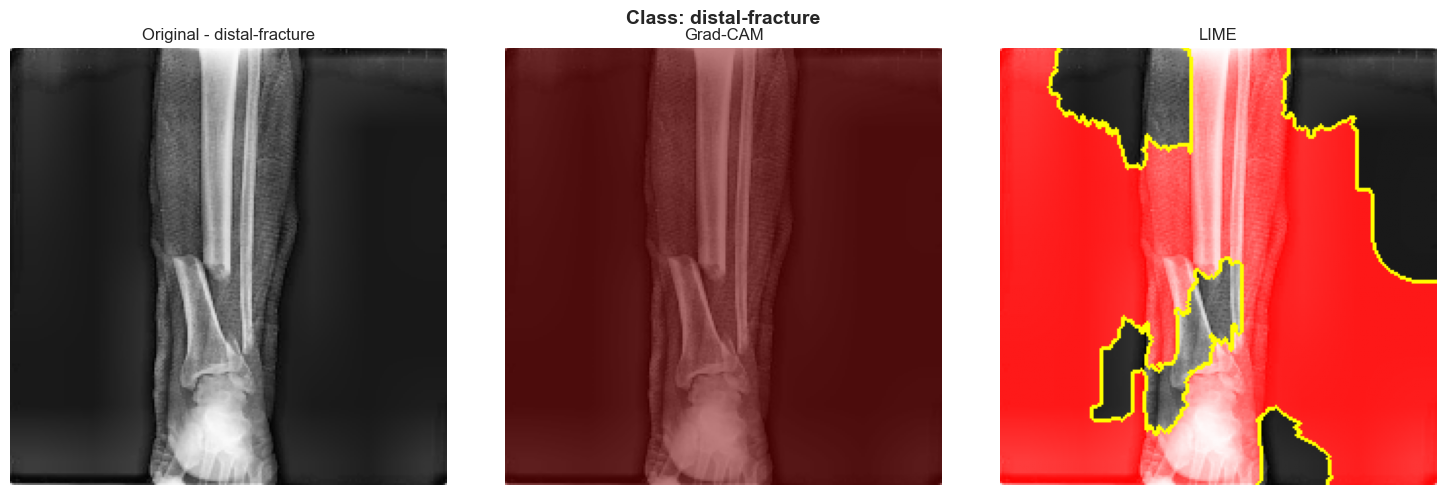

100%|██████████| 1000/1000 [00:14<00:00, 67.42it/s]


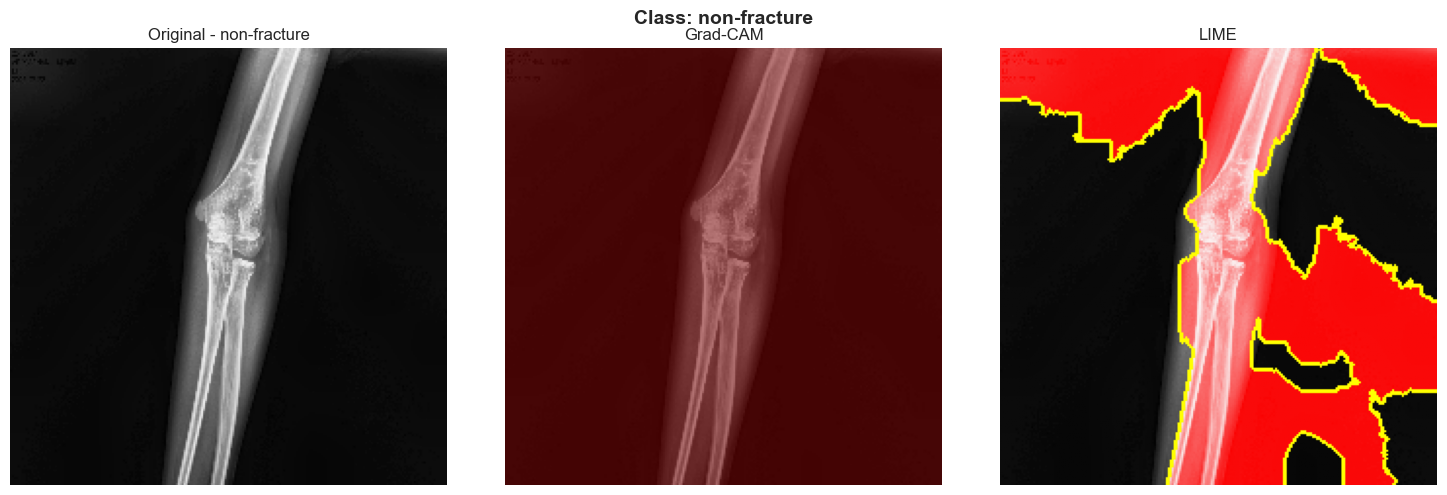

100%|██████████| 1000/1000 [00:15<00:00, 64.46it/s]


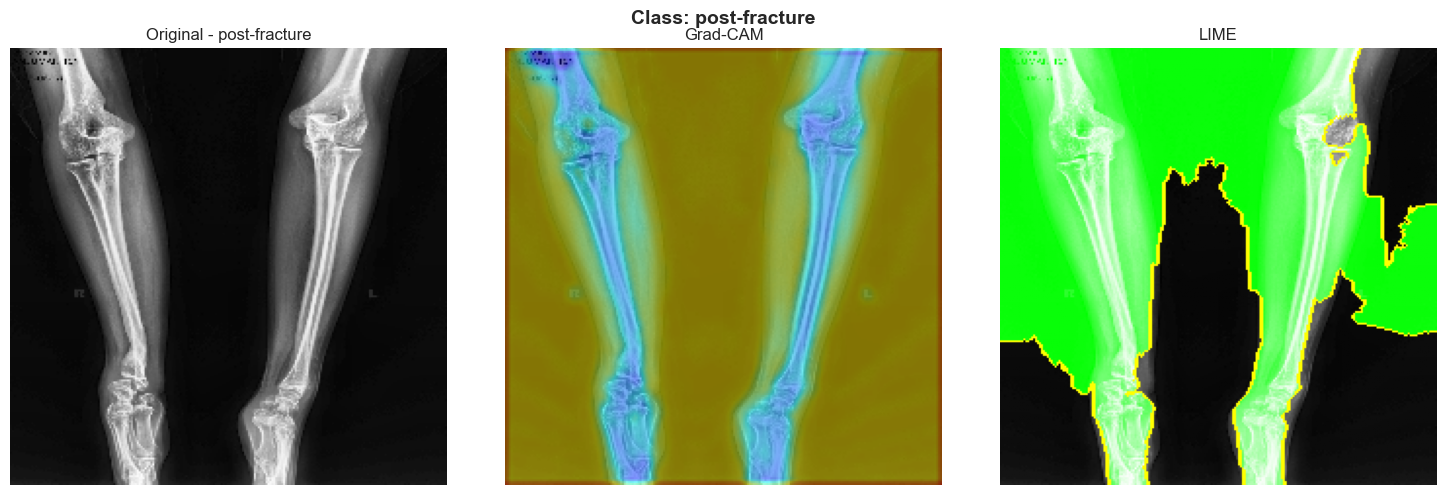

100%|██████████| 1000/1000 [00:15<00:00, 65.83it/s]


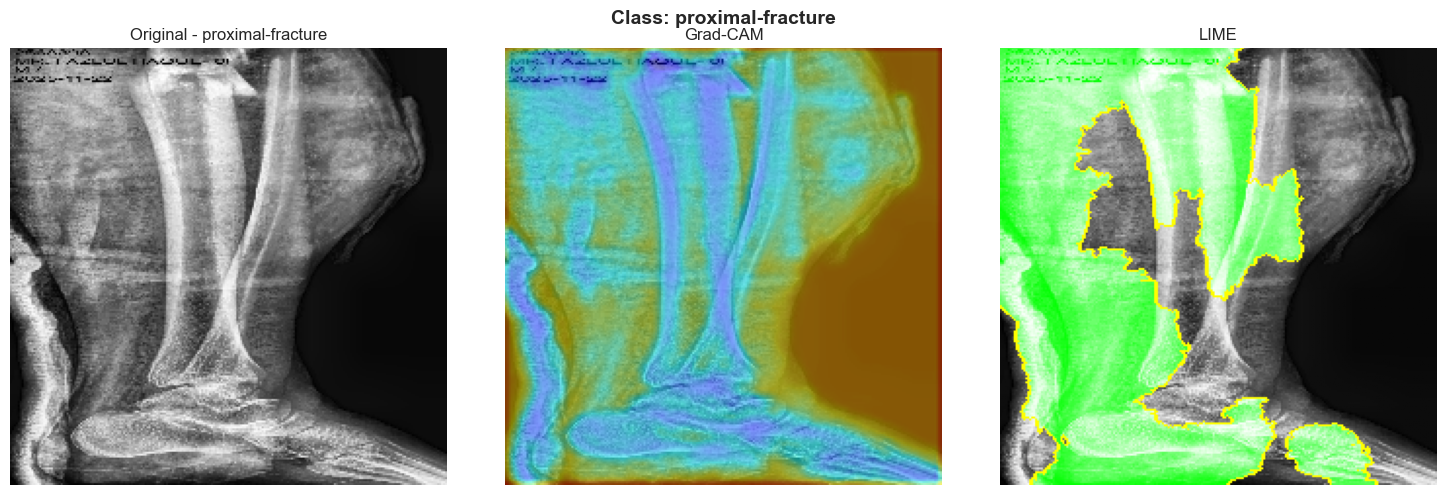


✓ Grad-CAM and LIME generated for each available class.

✅ FULL CNN MULTIMODAL PIPELINE COMPLETED (ROC INCLUDED)


In [2]:
# ======================================================================
# MULTIMODAL CNN WITH OVERSAMPLING + FULL EVAL + GRAD-CAM + LIME (ONE CELL)
# CSV DOES NOT CONTAIN fracture_type
# LABELS ARE TAKEN FROM IMAGE FOLDERS ONLY
# FULL EVALUATION RESTORED (CURVES + KAPPA + REPORT + ROC)
# ======================================================================

# -------------------- PROTOBUF FIX --------------------
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

# -------------------- IMPORTS --------------------
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score, cohen_kappa_score
)

from lime import lime_image
from skimage.segmentation import mark_boundaries
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# -------------------- GLOBAL CONFIG --------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224,224)
BATCH_SIZE = 64
EPOCHS = 30
NUM_CLASSES = 4

CLASS_NAMES = [
    'distal-fracture',
    'non-fracture',
    'post-fracture',
    'proximal-fracture'
]

BASE_DIR = Path(r"F:\Main data")
CSV_PATH = BASE_DIR / "bone_metadata.csv"

# -------------------- GPU CONFIG --------------------
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print("✓ GPU detected")
else:
    print("⚠ Running on CPU")

# ======================================================================
# 1. LOAD IMAGES (LABELS FROM FOLDERS)
# ======================================================================
IMG_DIR_MAP = {
    'distal-fracture': 'distal-fracture',
    'non-fracture': 'non-fracture',
    'post-fracture': 'post-fracture',
    'proximal-fracture': 'proximal-fracture'
}

image_paths, labels = [], []
for cls in CLASS_NAMES:
    for ext in ['*.jpg','*.png','*.jpeg']:
        for img in (BASE_DIR / IMG_DIR_MAP[cls]).glob(ext):
            image_paths.append(str(img))
            labels.append(cls)

img_df = pd.DataFrame({
    "image_path": image_paths,
    "fracture_type": labels
})

# ======================================================================
# 2. LOAD METADATA CSV (NO fracture_type)
# ======================================================================
df = pd.read_csv(CSV_PATH)
df['id_clean'] = df['id'].astype(str)
img_df['id_clean'] = img_df['image_path'].apply(lambda x: Path(x).stem)

merged_df = img_df.merge(df, on='id_clean', how='left')
merged_df.dropna(subset=['age','primary_observation'], inplace=True)

# ======================================================================
# 3. METADATA PREPROCESSING
# ======================================================================
categorical_cols = [
    'gender','bone_type','left_right',
    'gap_visibility','primary_observation'
]
numerical_cols = ['age','bone_width','fracture_gap']

label_encoders = {}
print("\n===== LABEL ENCODER MAPS =====")
for col in categorical_cols:
    merged_df[col] = merged_df[col].fillna("unknown")
    le = LabelEncoder()
    merged_df[col+"_encoded"] = le.fit_transform(merged_df[col])
    label_encoders[col] = le
    for i,c in enumerate(le.classes_):
        print(f"{col}: {c} → {i}")

for col in numerical_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
    merged_df[col].fillna(merged_df[col].median(), inplace=True)

scaler = StandardScaler()
merged_df[numerical_cols] = scaler.fit_transform(merged_df[numerical_cols])

metadata_cols = [c+"_encoded" for c in categorical_cols] + numerical_cols

X_images = merged_df['image_path'].values
X_meta = merged_df[metadata_cols].values

# ======================================================================
# 4. TARGET
# ======================================================================
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(merged_df['fracture_type'])

# ======================================================================
# 5. TRAIN / VAL / TEST SPLIT
# ======================================================================
X_img_tr, X_img_tmp, X_meta_tr, X_meta_tmp, y_tr, y_tmp = train_test_split(
    X_images, X_meta, y, test_size=0.2, stratify=y, random_state=SEED
)
X_img_val, X_img_te, X_meta_val, X_meta_te, y_val, y_te = train_test_split(
    X_img_tmp, X_meta_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED
)

# ======================================================================
# 6. OVERSAMPLING (TRAIN ONLY)
# ======================================================================
unique, counts = np.unique(y_tr, return_counts=True)
max_count = counts.max()

idxs = []
for c in unique:
    ids = np.where(y_tr==c)[0]
    ids = np.random.choice(ids, max_count, replace=True)
    idxs.append(ids)

idxs = np.concatenate(idxs)
np.random.shuffle(idxs)

X_img_tr = X_img_tr[idxs]
X_meta_tr = X_meta_tr[idxs]
y_tr = y_tr[idxs]

y_tr_cat = keras.utils.to_categorical(y_tr, NUM_CLASSES)
y_val_cat = keras.utils.to_categorical(y_val, NUM_CLASSES)
y_te_cat  = keras.utils.to_categorical(y_te, NUM_CLASSES)

# ======================================================================
# 7. DATA GENERATOR
# ======================================================================
class Gen(keras.utils.Sequence):
    def __init__(self, imgs, meta, labels, batch):
        self.imgs, self.meta, self.labels = imgs, meta, labels
        self.batch = batch
        self.idx = np.arange(len(imgs))
    def __len__(self):
        return int(np.ceil(len(self.imgs)/self.batch))
    def __getitem__(self,i):
        ids = self.idx[i*self.batch:(i+1)*self.batch]
        X1,X2,y = [],[],[]
        for j in ids:
            img = cv2.imread(self.imgs[j], cv2.IMREAD_GRAYSCALE)
            img = cv2.createCLAHE(3,(8,8)).apply(img)
            img = cv2.resize(img, IMG_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)/255.0
            X1.append(img)
            X2.append(self.meta[j])
            y.append(self.labels[j])
        return [np.array(X1),np.array(X2)],np.array(y)

train_gen = Gen(X_img_tr,X_meta_tr,y_tr_cat,BATCH_SIZE)
val_gen   = Gen(X_img_val,X_meta_val,y_val_cat,BATCH_SIZE)
test_gen  = Gen(X_img_te,X_meta_te,y_te_cat,BATCH_SIZE)

# ======================================================================
# 8. CNN MODEL (UNCHANGED)
# ======================================================================
img_in = layers.Input((224,224,3))
x = layers.Conv2D(32,3,padding='same',activation='relu')(img_in)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64,3,padding='same',activation='relu')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

meta_in = layers.Input((X_meta_tr.shape[1],))
m = layers.Dense(64,activation='relu')(meta_in)

f = layers.Concatenate()([x,m])
f = layers.Dense(128,activation='relu')(f)
out = layers.Dense(NUM_CLASSES,activation='softmax')(f)

model = Model([img_in,meta_in],out)
model.compile(
    Adam(1e-4),
    'categorical_crossentropy',
    ['accuracy',Precision(),Recall()]
)
model.summary()

# ======================================================================
# 9. TRAIN
# ======================================================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(patience=3,factor=0.4),
        keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True)
    ]
).history

# ======================================================================
# 10. FULL EVALUATION (WITH ROC CURVES)
# ======================================================================
y_prob = model.predict(test_gen)
y_pred = np.argmax(y_prob,1)
y_true = y_te

# ---- ACCURACY & LOSS CURVES ----
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['accuracy']); plt.plot(history['val_accuracy'])
plt.title("Accuracy Curve"); plt.legend(['Train','Val'])

plt.subplot(1,2,2)
plt.plot(history['loss']); plt.plot(history['val_loss'])
plt.title("Loss Curve"); plt.legend(['Train','Val'])
plt.show()

# ---- CONFUSION MATRIX ----
cm = confusion_matrix(y_true,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.show()

# ---- ROC CURVES (ONE-vs-REST) ----
plt.figure(figsize=(6,5))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- METRICS ----
print("\nClassification Report:\n")
print(classification_report(y_true,y_pred,target_names=CLASS_NAMES))
print("Cohen Kappa:",cohen_kappa_score(y_true,y_pred))
print("Weighted F1:",f1_score(y_true,y_pred,average='weighted'))

# ======================================================================
# 11. GRAD-CAM + LIME
# ======================================================================
def make_gradcam_heatmap(model, img_array, meta_array, class_index, last_conv_layer_name=None):
    """Generate Grad-CAM heatmap for multimodal model."""
    if last_conv_layer_name is None:
        # find last Conv2D layer automatically
        for layer in reversed(model.layers):
            if isinstance(layer, layers.Conv2D):
                last_conv_layer_name = layer.name
                break
    if last_conv_layer_name is None:
        raise ValueError("No Conv2D layer found for Grad-CAM.")

    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([img_array, meta_array])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    if grads is None:
        raise ValueError("Gradients are None in Grad-CAM.")

    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.zeros(conv_outputs.shape[:2])
    for i in range(conv_outputs.shape[-1]):
        heatmap += pooled_grads[0, i] * conv_outputs[:, :, i]

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()

def show_gradcam_on_image(original_img_uint8, heatmap, alpha=0.5):
    """Overlay Grad-CAM heatmap on original image (uint8 RGB)."""
    heatmap_resized = cv2.resize(heatmap, (original_img_uint8.shape[1], original_img_uint8.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(heatmap_color, alpha, original_img_uint8, 1 - alpha, 0)
    return overlay

def generate_lime_for_example(model, img_uint8, meta_vec, num_samples=1000):
    """Generate LIME explanation for a single image+metadata."""
    explainer = lime_image.LimeImageExplainer()

    def predict_fn(images):
        # images: list of HxWx3 uint8
        images = np.array(images).astype(np.float32) / 255.0
        meta_batch = np.repeat(meta_vec[np.newaxis, :], images.shape[0], axis=0)
        preds = model.predict([images, meta_batch], verbose=0)
        return preds

    explanation = explainer.explain_instance(
        img_uint8,
        predict_fn,
        top_labels=NUM_CLASSES,
        hide_color=0,
        num_samples=num_samples
    )
    return explanation

# ======================================================================
# 11. GRAD-CAM + LIME (FIXED VARIABLE NAMES ONLY)
# ======================================================================
print("\n=== Grad-CAM & LIME per class ===")

for class_idx, class_name in enumerate(CLASS_NAMES):
    indices = np.where(y_te == class_idx)[0]
    if len(indices) == 0:
        print(f"No test sample for class {class_name}, skipping.")
        continue

    idx = indices[0]
    img_path = X_img_te[idx]
    meta_vec = X_meta_te[idx]

    # Load & preprocess (IDENTICAL to training)
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    img_gray = clahe.apply(img_gray)
    img_gray = cv2.resize(img_gray, IMG_SIZE)
    img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    img_rgb_norm = img_rgb.astype(np.float32) / 255.0

    img_batch = np.expand_dims(img_rgb_norm, axis=0)
    meta_batch = np.expand_dims(meta_vec, axis=0)

    # ---- Grad-CAM ----
    heatmap = make_gradcam_heatmap(
        model, img_batch, meta_batch, class_index=class_idx
    )
    overlay = show_gradcam_on_image(img_rgb.astype(np.uint8), heatmap)

    # ---- LIME ----
    explanation = generate_lime_for_example(
        model, img_rgb.astype(np.uint8), meta_vec, num_samples=1000
    )
    temp, mask = explanation.get_image_and_mask(
        class_idx, positive_only=False, num_features=10, hide_rest=False
    )
    lime_vis = mark_boundaries(temp / 255.0, mask)

    # ---- Plot ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_rgb, cmap='gray')
    axes[0].set_title(f"Original - {class_name}")
    axes[0].axis('off')

    axes[1].imshow(overlay)
    axes[1].set_title("Grad-CAM")
    axes[1].axis('off')

    axes[2].imshow(lime_vis)
    axes[2].set_title("LIME")
    axes[2].axis('off')

    plt.suptitle(f"Class: {class_name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n✓ Grad-CAM and LIME generated for each available class.")

# ======================================================================
# 12. SAVE ARTIFACTS
# ======================================================================
model.save(BASE_DIR / "multimodal_cnn_final.h5")

joblib.dump({
    "label_encoders": label_encoders,
    "scaler": scaler,
    "metadata_cols": metadata_cols,
    "class_names": CLASS_NAMES,
    "target_encoder": y_encoder
}, BASE_DIR / "preprocessing_artifacts.pkl")

print("\n✅ FULL CNN MULTIMODAL PIPELINE COMPLETED (ROC INCLUDED)")
